# Differentiable rasterization

This notebook illustrates the use of `sj.argmax` and fuzzy logic for writing a simple differentiable renderer based on [SoftRas](https://github.com/ShichenLiu/softRas). The tutorial has been inspired by [Sebastian League's video on rasterization](https://www.youtube.com/watch?v=yyJ-hdISgnw). At the end of this tutorial, we use the differentiable rasterizer to recover an object's 3D pose from a single
image using gradient descent.

A rasterizer has to answer two questions to render 2D images from 3D mesh vertices:
1. **Coverage** — does a pixel $p$ fall inside each triangle $abc$ (after projection onto the camera plane)? A yes/no test.
2. **Depth buffering** — of all the triangles covering $p$, which one is nearest? An `argmin`
   over depth.

Both are discrete oprators, so both have zero gradient. In turn, nudging a vertex either
changes nothing, or flips a pixel discontinuously.

## Setup

The pipeline boilerplate — camera and transform types, vertex projection, the OBJ loader —
lives in `rasterizer.py` next to this notebook. We import these functions and write out by hand only
the three functions where softjax is being used.

In [1]:
import sys
from functools import partial
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "rasterizer.py").exists():
    HERE = (Path.cwd() / "docs/examples/rasterizer").resolve()
sys.path.insert(0, str(HERE))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from rasterizer import (
    barycentric_coordinates,
    Camera,
    load_obj,
    Model,
    normal_shader,
    pixel_grid,
    process_model,
    RasterizedModel,
    RenderTarget,
    rotation_x,
    rotation_y,
    safe_division,
    SceneData,
    Transform,
)

import softjax as sj

_EPS = 1e-10


def panels(items, ncols, figsize=2.9, suptitle=None, outline=None):
    """Grid of imshow panels. `items` is a list of (title, image, kwargs)."""
    nrows = (len(items) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(figsize * ncols, figsize * nrows),
        constrained_layout=True, squeeze=False,
    )
    for ax, (title, img, kw) in zip(axes.ravel(), items):
        im = ax.imshow(jnp.asarray(img), **kw)
        if outline is not None:
            xs = [float(v[0]) for v in outline] + [float(outline[0][0])]
            ys = [float(v[1]) for v in outline] + [float(outline[0][1])]
            ax.plot(xs, ys, color="white", linewidth=1.2)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, shrink=0.72)
    for ax in axes.ravel()[len(items):]:
        ax.set_visible(False)
    if suptitle:
        fig.suptitle(suptitle, fontsize=11)
    plt.show()

## Determine if projected mesh triangle covers pixel location

A point $p$ lies inside triangle $abc$ exactly when all three of its barycentric
coordinates are non-negative:

$$\text{inside}(p) \;=\; [b_1 \ge 0] \,\wedge\, [b_2 \ge 0] \,\wedge\, [b_3 \ge 0]$$

Written with ordinary comparisons this is a hard boolean. The softjax version swaps each
`>=` for [`sj.greater_equal`][softjax.greater_equal] and the `and` for
[`sj.all`][softjax.all], turning `inside` into a value in $[0, 1]$ — being the *probability* of coverage.

`mode="hard"` recovers the exact test; `mode="smooth"` gives the relaxation, with
`softness` setting how far the influence of the triangle bleeds past its edges.

In [2]:
def point_in_triangle(a, b, c, p, mode="smooth", softness=0.1):
    """Soft coverage test + barycentric weights for pixels `p` of shape (..., 2).

    Returns `(inside, w_a, w_b, w_c)`. `inside` is a probability;
    the weights are the clipped, renormalized barycentric coordinates.
    """
    b1, b2, b3, _, _, _ = barycentric_coordinates(a, b, c, p)

    inside = sj.all(
        jnp.stack(
            [
                sj.greater_equal(b1, 0.0, mode=mode, softness=softness, epsilon=_EPS),
                sj.greater_equal(b2, 0.0, mode=mode, softness=softness, epsilon=_EPS),
                sj.greater_equal(b3, 0.0, mode=mode, softness=softness, epsilon=_EPS),
            ],
            axis=-1,
        ),
        axis=-1,
    )

    # Clip barycentric coordinates to range [0.0, 1.0] as the resulting
    # weights are used for color / texture interpolation
    w_a, w_b, w_c = (jnp.clip(bi, 0.0, 1.0) for bi in (b1, b2, b3))
    total = w_a + w_b + w_c
    return (
        inside,
        safe_division(w_a, total),
        safe_division(w_b, total),
        safe_division(w_c, total),
    )

Let's evaluate `point_in_triangle()` over a grid  of pixel locations and using only a single mesh triangle. The
variable `inside` is the probability that the triangle covers the respective pixel. 
Note, how the **smooth: inside** function has non-zero values outside the triangle.
The three weight fields are **identical** in both rows, because `mode` touches only the computation of `inside`.

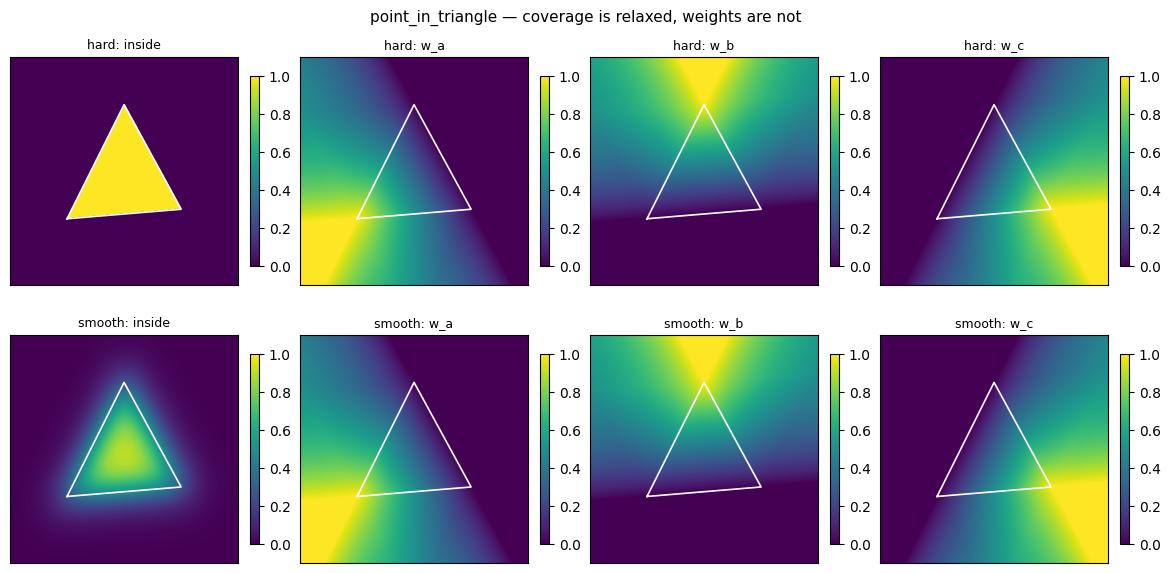

In [3]:
tri_a = jnp.array([0.20, 0.25])
tri_b = jnp.array([0.50, 0.85])
tri_c = jnp.array([0.80, 0.30])

grid = jnp.stack(jnp.meshgrid(
    jnp.linspace(-0.1, 1.1, 400), jnp.linspace(-0.1, 1.1, 400), indexing="xy",
), axis=-1)

extent = dict(extent=(-0.1, 1.1, -0.1, 1.1), origin="lower", cmap="viridis")
items = []
for label, mode in [("hard", "hard"), ("smooth", "smooth")]:
    fields = point_in_triangle(tri_a, tri_b, tri_c, grid, mode=mode, softness=0.1)
    for name, field in zip(["inside", "w_a", "w_b", "w_c"], fields):
        items.append((f"{label}: {name}", field, dict(**extent, vmin=0.0, vmax=1.0)))

panels(items, ncols=4, suptitle="point_in_triangle — coverage is relaxed, weights are not",
       outline=[tri_a, tri_b, tri_c])

As shown in the plot below inreasing the `softness` spreads out the `inside` coverage probability beyond the edges of the triangle.

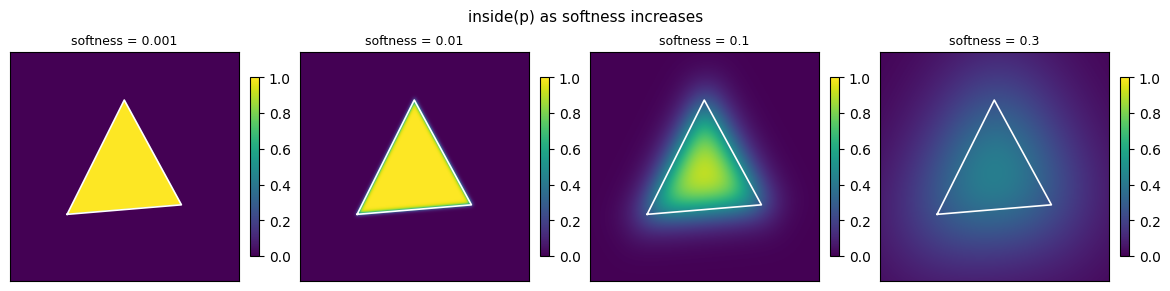

In [4]:
panels(
    [
        (f"softness = {s:g}",
         point_in_triangle(tri_a, tri_b, tri_c, grid, "smooth", s)[0],
         dict(**extent, vmin=0.0, vmax=1.0))
        for s in [1e-3, 1e-2, 1e-1, 3e-1]
    ],
    ncols=4, suptitle="inside(p) as softness increases", outline=[tri_a, tri_b, tri_c],
)

In turn, the gradient of `inside` is non-zero at the triangle vertex `tri_a`.

In [5]:
def total_coverage(vertex_a, mode, softness=0.1):
    return jnp.sum(point_in_triangle(vertex_a, tri_b, tri_c, grid, mode, softness)[0])


for mode in ["hard", "smooth"]:
    g = jax.grad(partial(total_coverage, mode=mode))(tri_a)
    print(f"{mode:7s} d(coverage)/d(vertex a) = [{g[0]:+.3f}, {g[1]:+.3f}]")

hard    d(coverage)/d(vertex a) = [+0.000, +0.000]
smooth  d(coverage)/d(vertex a) = [-33068.977, -17919.641]


## Shading

With coverage handled, shading a triangle is straightforward: interpolate the per-vertex
attributes (depth, UV, normal) with the barycentric weights and hand them to a shader.
Nothing here is discrete, so nothing here needs relaxing.

In [6]:
def rasterize_triangle(triangle, h, w, shader, mode="smooth", softness=0.1):
    """Shade one triangle over an H x W pixel grid.

    Returns `(color, depth, inside)` of shapes (H, W, 3), (H, W), (H, W).
    """
    a, b, c = triangle.screen_pos[0], triangle.screen_pos[1], triangle.screen_pos[2]

    p = pixel_grid(h, w)  # (H, W, 2)
    inside, w_a, w_b, w_c = point_in_triangle(a, b, c, p, mode, softness)
    weights = jnp.stack([w_a, w_b, w_c], axis=-1)  # (H, W, 3)

    depth = weights @ triangle.depth
    tex_coord = weights @ triangle.tex_coords
    normal = weights @ triangle.normals

    return shader(p, tex_coord, normal, depth), depth, inside

Using the barycentric coordinates to interpolate the depth values of the triangle vertices yields nearly identical results for `mode=hard` and `mode=soft`.

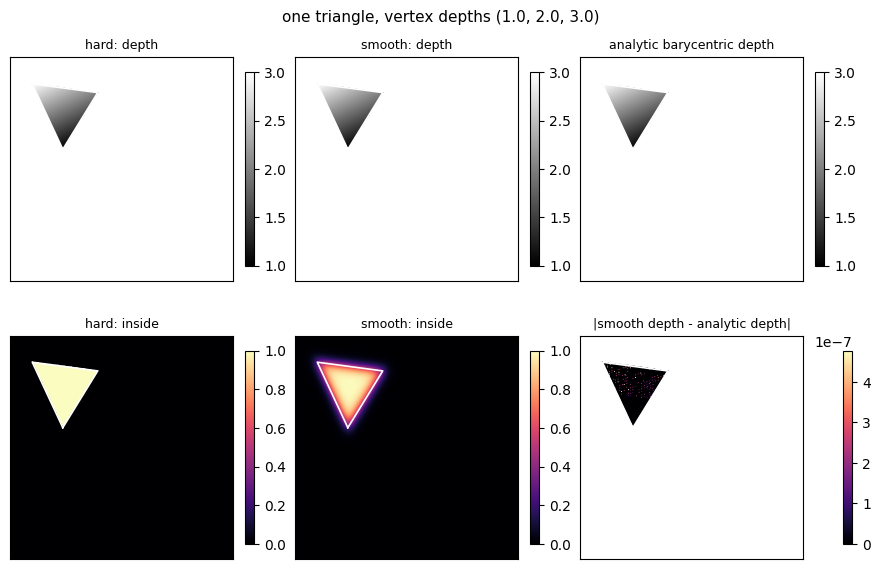

In [18]:
H = W = 256
screen_pos = 0.5 * jnp.array([[120.0, 210.0], [200.0, 80.0], [50.0, 60.0]])
vertex_depths = jnp.array([1.0, 2.0, 3.0])

triangle = RasterizedModel(
    depth=vertex_depths,
    screen_pos=screen_pos,
    tex_coords=jnp.zeros((3, 2)),
    normals=jnp.zeros((3, 3)),
)
no_shader = lambda p, tex, nrm, d: jnp.zeros((*p.shape[:-1], 3))

_, depth_hard, inside_hard = rasterize_triangle(triangle, H, W, no_shader, "hard", 0.05)
_, depth_soft, inside_soft = rasterize_triangle(triangle, H, W, no_shader, "smooth", 0.05)

# Analytic linear-barycentric depth over the whole grid, for reference.
b1, b2, b3, *_ = barycentric_coordinates(*screen_pos, pixel_grid(H, W))
depth_gt = b1 * vertex_depths[0] + b2 * vertex_depths[1] + b3 * vertex_depths[2]

# Depth is only meaningful where the triangle actually is; blank the outside
# so the interior ramp is what you see.
covered = inside_hard > 0.5
mask = lambda d: jnp.where(covered, d, jnp.nan)

d_kw = dict(cmap="grey", vmin=1.0, vmax=3.0)
i_kw = dict(cmap="magma", vmin=0.0, vmax=1.0)
panels(
    [
        ("hard: depth", mask(depth_hard), d_kw),
        ("smooth: depth", mask(depth_soft), d_kw),
        ("analytic barycentric depth", mask(depth_gt), d_kw),
        ("hard: inside", inside_hard, i_kw),
        ("smooth: inside", inside_soft, i_kw),
        ("|smooth depth - analytic depth|", mask(jnp.abs(depth_soft - depth_gt)),
dict(cmap="magma")),
    ],
    ncols=3, suptitle=f"one triangle, vertex depths {tuple(float(v) for v in vertex_depths)}",
    outline=screen_pos,
)

## Depth buffering
Given an image of size $H \times W$ and $N$ triangles, the function `rasterize_triangle` (vmapiing over the function `point_in_triangle`) gives rise to an array $P$ of size $N \times H \times W$ containing the aforementioned coverage probabilities $p_j^i$.

As next step, it is determined which of the triangles is close to the image pixels.
To do so, following SoftRas, the pixel-vertex-wise depth values $d_j^i$ are transformed to inverse depth $z_j^i$ such that $1$ corresponds to the nearest vertex and $0$ to the vertex that is furthest away from the respective pixel. In turn, a weight for each pixel-vertex pair is obtained through a weighted soft-argmax as

$$
    w_j^i = \frac{p_j^i \exp(z_j^i/\tau_2)}{\sum_{k} p_k^i \exp(z_k^i/\tau_2)}
$$

which we implemented using $\operatorname{argmax}_{\tau_2}$ and noting that $b\exp(a)=\exp(a + \log(b))$ if $b>0$.

Note that the background is incorporated into the above equation by appending an array of ones of size $1 \times H \times W$ to $P$ as well as appending an array of size $1 \times H \times W$ containing a small number $\epsilon$ to the arrays of inverse depths.
Subsequently, given $w_j^i$, the color of each image pixel is obtained as $I^i=\sum_jw_j^iC_j^i$. Note that the color aggregation operation equals the computation of an expectation using SoftJax's `take_along_axis` operator.

In [19]:
@partial(jax.jit, static_argnames="mode")
def render(target, scene_data, mode="smooth", softness_depth=1e-1,
           softness_inside=1e-1, background_color=0.0):
    """Composite every model in `scene_data` into `target`."""
    h, w = target.color_buffer.shape[:2]

    # Project + shade every triangle of every model, in parallel.
    per_model = []
    for model_i in scene_data.models:
        projected = process_model(model_i, scene_data.camera, target)
        per_model.append(
            jax.vmap(lambda tri, shader=model_i.shader: rasterize_triangle(
                tri, h, w, shader, mode, softness_inside))(projected)
        )
    # (n_tris, H, W, 3), (n_tris, H, W), (n_tris, H, W)
    colors, depths, insides = jax.tree.map(
        lambda *xs: jnp.concatenate(xs, axis=0), *per_model)

    # Normalize and invert depth so that "nearer" is "larger".
    normed = (jnp.max(depths) - depths) / (jnp.max(depths) - jnp.min(depths))

    # Append a background slice: farthest, fully covering, constant colour.
    normed = jnp.r_[normed, jnp.full((1, h, w), _EPS)]
    depths = jnp.r_[depths, jnp.full((1, h, w), jnp.max(depths))]
    colors = jnp.r_[colors, jnp.full((1, h, w, 3), background_color)]
    insides = jnp.r_[insides, jnp.ones((1, h, w))]

    # --- the second discrete decision, relaxed ----------------------------
    score = normed / softness_depth + jnp.log(insides + _EPS)
    weights = jnp.moveaxis(
        sj.argmax(score, axis=0, mode=mode, softness=1.0, standardize=False), -1, 0)

    return RenderTarget(
        color_buffer=jnp.sum(weights[..., None] * colors, axis=0),
        depth_buffer=jnp.sum(weights * depths, axis=0),
    )

That is the whole renderer. Let's load a mesh and rotate it on a turntable to the the rendering. As color values, we use a simple normal shader (colouring the vertices depending on their normal direction).

Note how in the rendered images each triangle contributes a little to every pixel, which is precisely what gives the
renderer a gradient with respect to geometry. Large flat polygons (the hair and hat here) spread furthest, because coverage softness is measured in barycentric units and those are largest for big triangles. Turning `softness_inside` down tightens the halo and, with it,
the gradient.

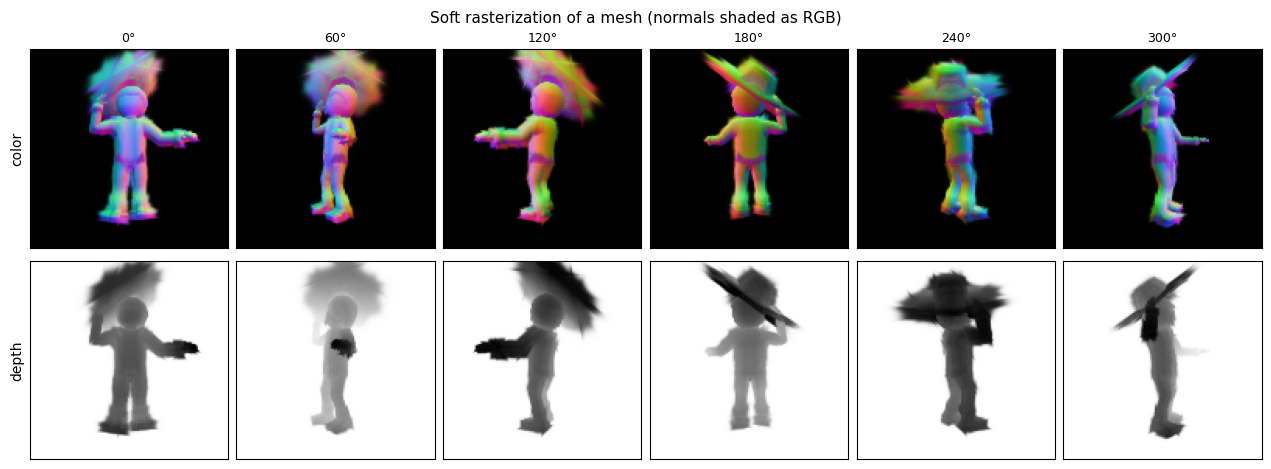

In [20]:
vertices, normals, tex_coords = load_obj(HERE / "meshes" / "dave.obj", verbose=False)
RES = 128

camera = Camera(
    fov=jnp.asarray(jnp.pi / 3),
    transform=Transform(position=jnp.array([0.0, 0.0, -3.0]), rotation=jnp.eye(3)),
)


def blank_target(res=RES):
    return RenderTarget(
        color_buffer=jnp.zeros((res, res, 3)),
        depth_buffer=jnp.full((res, res), jnp.inf),
    )


def turntable_scene(angle_rad):
    model = Model(
        vertices=vertices, tex_coords=tex_coords, normals=normals,
        transform=Transform(
            position=jnp.array([0.0, 1.1, 0.0]),
            rotation=rotation_y(angle_rad) @ rotation_x(jnp.deg2rad(180.0)),
            scale=jnp.asarray(1.3),
        ),
        shader=normal_shader,
    )
    return SceneData(camera=camera, models=[model])


angles = jnp.deg2rad(jnp.array([0.0, 60.0, 120.0, 180.0, 240.0, 300.0]))
frames = [render(blank_target(), turntable_scene(a)) for a in angles]

fig, axes = plt.subplots(2, len(angles), figsize=(2.1 * len(angles), 4.6),
                         constrained_layout=True)
for col, (ax_c, ax_d, frame, ang) in enumerate(
        zip(axes[0], axes[1], frames, jnp.rad2deg(angles))):
    ax_c.imshow(jnp.clip(frame.color_buffer, 0.0, 1.0))
    ax_c.set_title(f"{float(ang):.0f}°", fontsize=9)
    ax_d.imshow(frame.depth_buffer, cmap="gray")
    for ax in (ax_c, ax_d):
        ax.set_xticks([])
        ax.set_yticks([])
axes[0, 0].set_ylabel("color", fontsize=10)
axes[1, 0].set_ylabel("depth", fontsize=10)
fig.suptitle("Soft rasterization of a mesh (normals shaded as RGB)", fontsize=11)
plt.show()

## Pose estimation with differentiable rendering
The gradients of the differentiable renderer can be used to estimate an object's pose by inverse rendering.
Starting from a wrong pose, we minimise the L2 distance between the target image and a **softly** rendered image using `jax.grad`.

The rotation is parameterized as a $3\times3$ matrix projected onto $SO(3)$ via a SVD decomposition (see [here](https://github.com/martius-lab/hitchhiking-rotations) if you want to learn more about learning with rotations).

In [21]:
FIT_RES = 64
sphere_v, sphere_n, sphere_t = load_obj(HERE / "meshes" / "sphere.obj", verbose=False)


def project_so3(m):
    """Nearest rotation matrix to `m`, via symmetric orthogonalization."""
    U, _, Vh = jnp.linalg.svd(m, full_matrices=False)
    det = jnp.linalg.det(U @ Vh)
    return jnp.c_[U[:, :-1], U[:, -1] * det] @ Vh


def geodesic_deg(r_a, r_b):
    """Geodesic distance between two rotations, in degrees."""
    cos = (jnp.trace(r_a.T @ r_b) - 1.0) / 2.0
    return jnp.rad2deg(jnp.arccos(jnp.clip(cos, -1.0, 1.0)))


def render_sphere(rotation, position, mode):
    sphere = Model(
        vertices=sphere_v, tex_coords=sphere_t, normals=sphere_n,
        transform=Transform(position=position, rotation=rotation,
                            scale=jnp.asarray(0.7)),
        shader=normal_shader,
    )
    scene = SceneData(camera=camera, models=[sphere])
    return render(blank_target(FIT_RES), scene, mode=mode).color_buffer


R_true = rotation_y(jnp.deg2rad(90.0)) @ rotation_x(jnp.deg2rad(180.0))
t_true = jnp.array([0.6, 0.6, 0.0])
target_image = render_sphere(R_true, t_true, mode="hard")

In [29]:
n_steps, learning_rate = 300, 1e-1
params = (jnp.diag(jnp.array([1.3, 1.1, 0.9])), jnp.array([-0.6, -0.6, 0.0]))

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


def loss_fn(params):
    matrix, translation = params
    pred = render_sphere(project_so3(matrix), translation, mode="smooth")
    return jnp.mean((pred - target_image) ** 2)


@jax.jit
def make_step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), opt_state, loss


snapshot_steps = [0, 25, 75, 150, n_steps - 1]
losses, rot_errors, pos_errors, snapshots = [], [], [], []

for step in range(n_steps):
    params, opt_state, loss = make_step(params, opt_state)
    matrix, translation = params
    losses.append(float(loss))
    rot_errors.append(float(geodesic_deg(project_so3(matrix), R_true)))
    pos_errors.append(float(jnp.linalg.norm(translation - t_true)))
    if step in snapshot_steps:
        snapshots.append(
            (step, render_sphere(project_so3(matrix), translation, mode="hard")))

print(f"L2 image loss  {losses[0]:.3e}  ->  {losses[-1]:.3e}")
print(f"rotation error {rot_errors[0]:7.1f} deg  ->  {rot_errors[-1]:.2f} deg")
print(f"position error {pos_errors[0]:7.2f}      ->  {pos_errors[-1]:.3f}")

ValueError: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory

As shown in the plots below, we can recover the objects pose via gradient descent using a differentiable renderer written with SoftJax.

Yippee! 🥳🎉

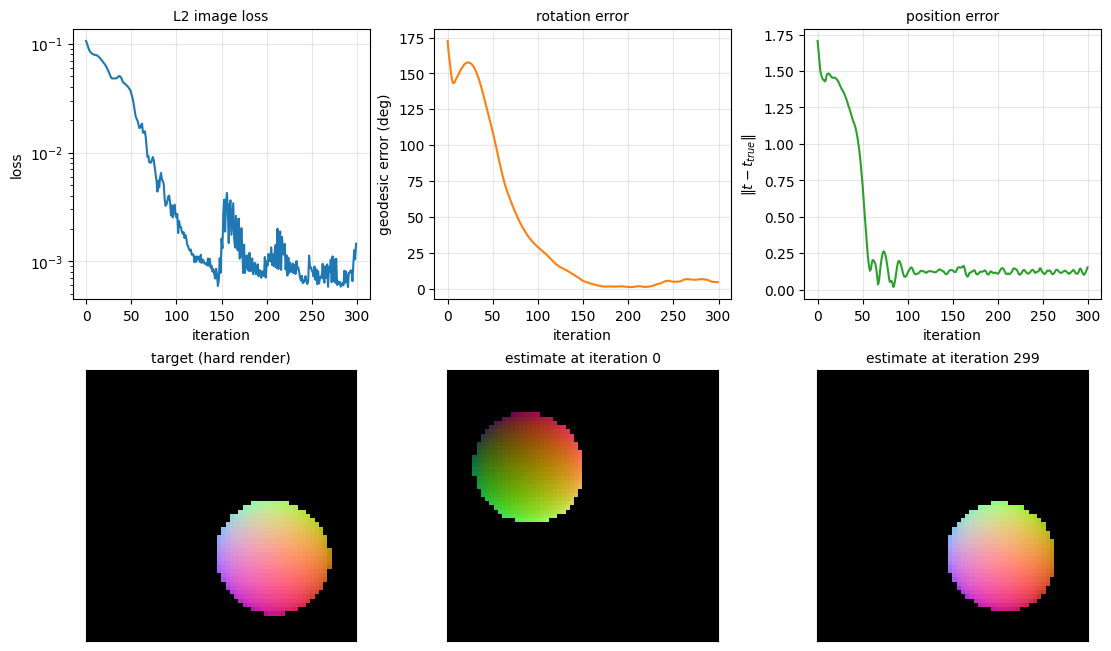

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), constrained_layout=True)

for ax, (values, title, ylabel, color) in zip(axes[0], [
    (losses, "L2 image loss", "loss", "C0"),
    (rot_errors, "rotation error", "geodesic error (deg)", "C1"),
    (pos_errors, "position error", r"$\|t - t_{true}\|$", "C2"),
]):
    (ax.semilogy if title.startswith("L2") else ax.plot)(values, color=color)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("iteration")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[1, 0].imshow(jnp.clip(target_image, 0.0, 1.0))
axes[1, 0].set_title("target (hard render)", fontsize=10)
for ax, (step, img) in zip(axes[1, 1:], [snapshots[0], snapshots[-1]]):
    ax.imshow(jnp.clip(img, 0.0, 1.0))
    ax.set_title(f"estimate at iteration {step}", fontsize=10)
for ax in axes[1]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

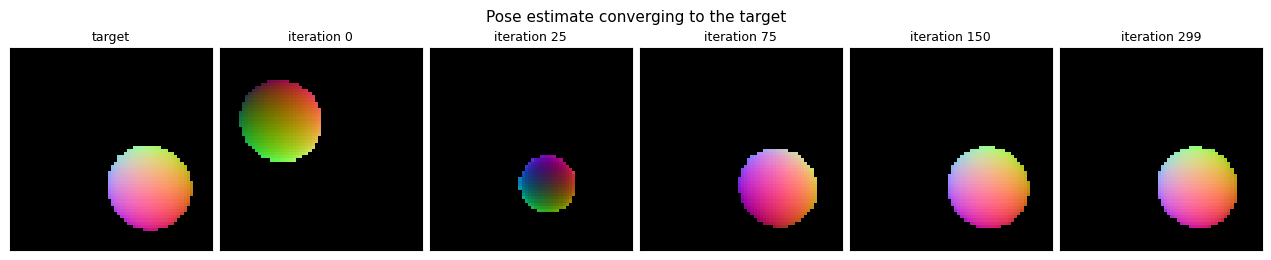

In [ ]:
fig, axes = plt.subplots(1, len(snapshots) + 1, figsize=(2.1 * (len(snapshots) + 1), 2.6),
                         constrained_layout=True)
axes[0].imshow(jnp.clip(target_image, 0.0, 1.0))
axes[0].set_title("target", fontsize=9)
for ax, (step, img) in zip(axes[1:], snapshots):
    ax.imshow(jnp.clip(img, 0.0, 1.0))
    ax.set_title(f"iteration {step}", fontsize=9)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Pose estimate converging to the target", fontsize=11)
plt.show()